# Computer Vision Garbage Classifier

### Background
Waste sorting allows for the diversion of waste from landfills through reuse, repair, refurbishment, re-manufacturing, repurposing, recycling and composting. This can reduce pressure on natural systems, communities and public health through the decreased demand of processing raw materials.
<br>

As waste generators, we are encouraged to sort waste by type (recycling, organics, metals, papers, etc.) when we are disposing of it, but due to the increasing complicated waste categorization, it has become difficult for to know how to correctly dispose of waste. Traditionally, this means that waste needs to be sorted for a second time at a waste processing plant through either direct (gravity, magnets, manual sorting) or indirect (sensors + robots) methods. With the modern advancements of deep learning, computer vision has become a feasible alternative to traditional indirect sorting methods (HSI cameras, X-ray, etc.) due to its feeble requirements of simple, inexpensive, and easy to maintain RGB cameras.
<br>

This cheaper technology has the potential to help improve waste sorting, both by alerting waste generators of the proper waste disposal method for solid waste at the source and improve waste sorting facilities. Deep learning enabled these advancements, with visual features displayed by different waste types being automatically learned from big data and improved robustness through feeding DL models with more visual data. 							

### What can we do to solve that?
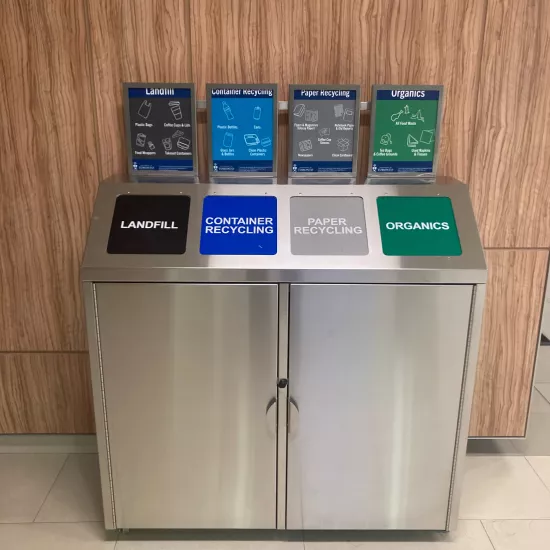](https://www.utm.utoronto.ca/green/sites/files/green/styles/call_to_action_image/public/2023-06/IMG_2376_Original_0.jpg.webp?itok=9cx7H3-1)

Your design team has been asked to develop a artificial intelligence system to help students and faculty on campus properly dispose of their waste. Due to the relatively low cost to outfit each recycling station with RGB cameras, a Computer Vision system has been requested. 
<br>

You will have the rest of the day to develop a prototype for this waste classification system.

## Train model
Train our waste classification CV model by using [Teachable Machine](https://teachablemachine.withgoogle.com/train/image) model using photos of different types of waste.   

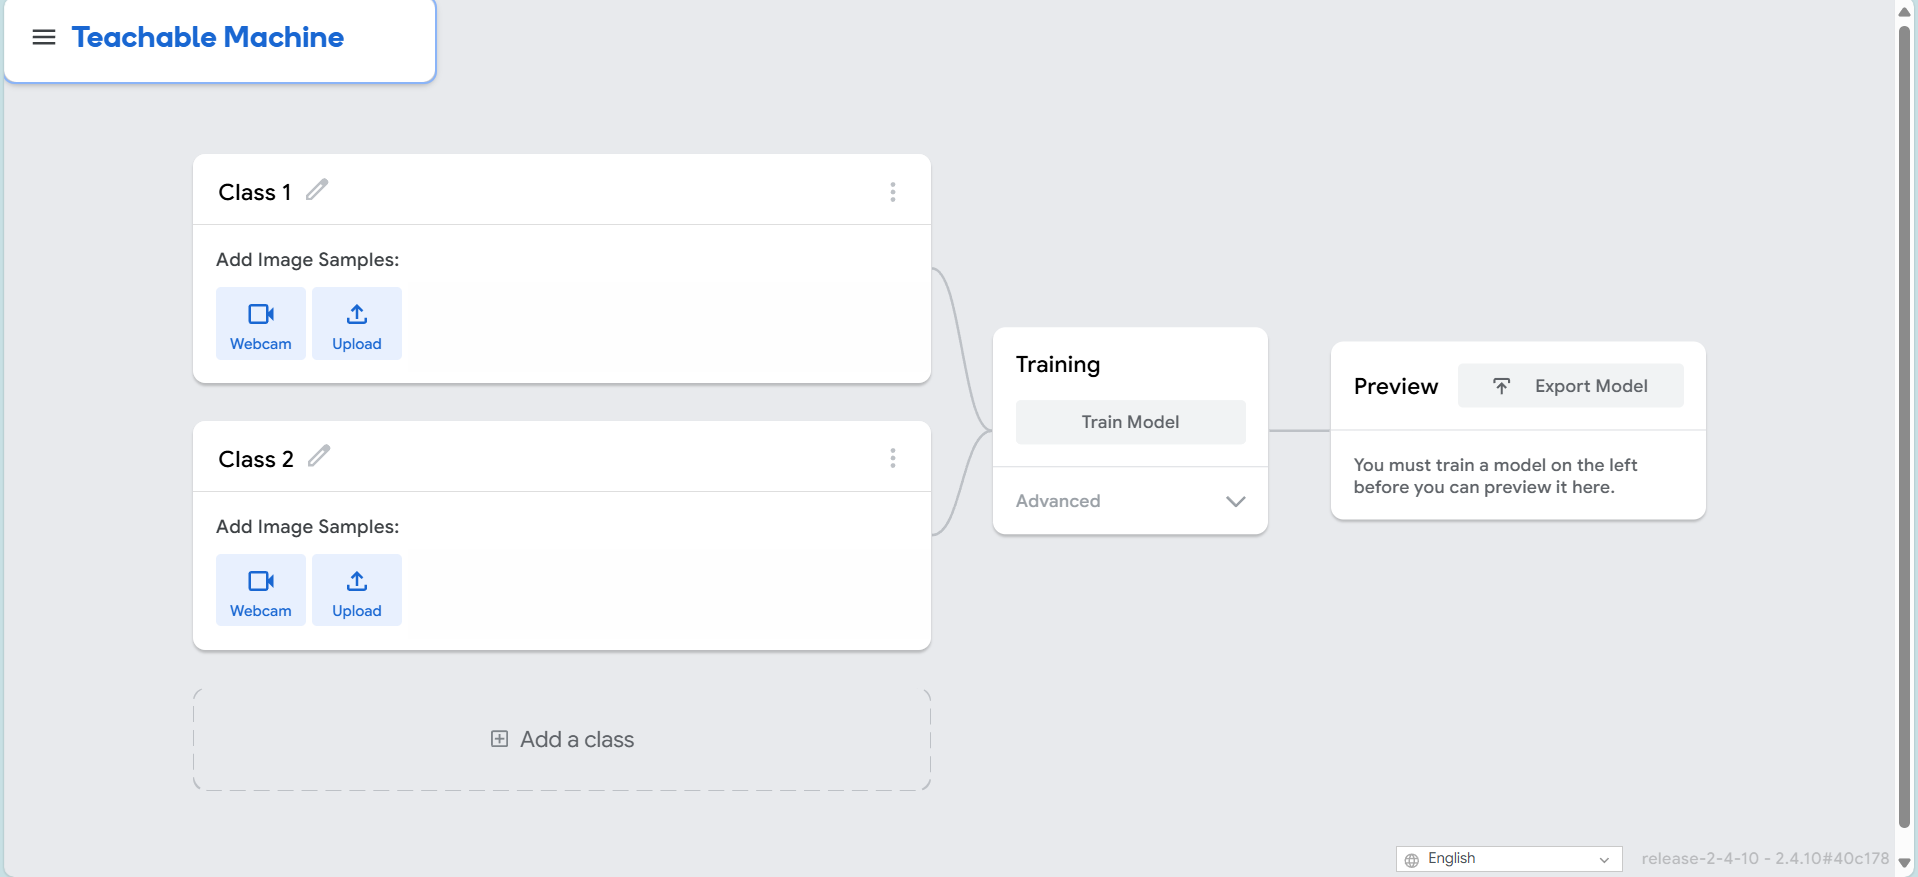

1. Create a New Project:
    
    - Click on "Get Started" and choose the "Image Project" option.

2. Set Up Classes:
    
    - You'll need to create a class for each type of waste you want to classify (e.g., plastic, glass, metal, cardboard).
    - Click on "Add a class" to create multiple classes.

3. Upload Images:
    
    - For each class, upload images that represent that type of waste. You can either drag and drop images or use your webcam to capture them.
    - Make sure to have a good variety of images for each class to improve the model's accuracy.
    - Make sure to rename each class so it is identifiable later. 

4. Train the Model:
    
    - Once you have uploaded enough images for each class, click on the "Train Model" button.
    - Teachable Machine will use these images to train a neural network to recognize the different types of waste.

5. Adjust Training Settings (Optional):
    
    - You can adjust settings like epochs (number of training cycles) and batch size (number of images processed at a time) to fine-tune the training process.

6. Test the Model:
    
    - After training, you can test the model by uploading new images or using your webcam to see how well it classifies the waste.

7. Exporting your Model:
    - 

### Import libraries
Libraries: OpenCV, Numpy, Pandas <br>
Modules: load_model from keras.modules


#### Install Libraries
The following libraries need to be installed: *tensorflow*, *opencv-python*, *numpy*, and *pandas*

In [1]:
# DO NOT MODIFY THIS CODE
# Install libraries if not already installed
%pip install tensorflow opencv-python numpy pandas pillow

Note: you may need to restart the kernel to use updated packages.


#### Import Libraries

In [2]:
# DO NOT MODIFY THIS CODE

import cv2  # Import opencv-python
import h5py  # Import h5py to read HDF5 files
import numpy as np  # Import numpy for numerical operations
import pandas as pd  # Import pandas for data manipulation
from keras.models import load_model  # TensorFlow is required for Keras to work
from PIL import Image, ImageTk  # Import PIL for image processing
import tkinter as tk  # Import tkinter for GUI

# Disable scientific notation for clarity
np.set_printoptions(suppress=True)


## Load Model and Labels
After training model using Teachable Machine, export the model in the Tensoflow Keras format.

### Load Model

The following cell reformats the .h5 file provided by Google Colab to ensure that it is compatible with new versions of Python and the Tensorflow library.

In [3]:
f = h5py.File("keras_model.h5", mode="r+") # Replace "..." with the path to your HDF5 file

# DO NOT MODIFY THIS CODE
model_config_string = f.attrs.get("model_config") 

if model_config_string.find('"groups": 1,') != -1: 
    model_config_string = model_config_string.replace('"groups": 1,', '') 

f.attrs.modify('model_config', model_config_string) 
f.flush() 

model_config_string = f.attrs.get("model_config") 

assert model_config_string.find('"groups": 1,') == -1 

Load .h5 model and its labels. 

In [4]:
# Load the model
model = load_model("keras_model.h5", compile=False) # Replace ... with the path to your model file. If it is in the same directory, you can use "model.h5" or similar.

model.summary()  # Print the model summary to understand its architecture

c:\ProgramData\anaconda3\envs\design_project_conda_env\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 1280)           │       410,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 9)              │       129,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539,208 (2.06 MB)

 Trainable params: 525,128 (2.00 MB)

 Non-trainable params: 14,080 (55.00 KB)

In [5]:
# Load the labels
class_names = open("labels.txt", "r").readlines() # Replace ... with the path to your labels file. If it is in the same directory, you can use "labels.txt" or similar.

class_names

['0 Paper Plate\n',
 '1 Battery\n',
 '2 Soda Can\n',
 '3 Toilet Paper Roll\n',
 '4 Egg Carton\n',
 '5 Tin Foil\n',
 '6 Wood Stick\n',
 '7 Folder\n',
 '8 Paper\n']

### Set Program Wide Font Settings

#### Colour & Font Type

The colour variable needs to a tuple with length 3, representing Blue, Green, Red values. <br><br>
Different font types on [Code Yarns' blog](https://codeyarns.com/tech/2015-03-11-fonts-in-opencv.html#gsc.tab=0).


In [6]:
# YOUR CODE STARTS HERE (REPLACE ... WITH YOUR SOLUTION)
font = cv2.FONT_HERSHEY_DUPLEX # Font type
fontScale = 2 # Font scale
color = (240, 250, 100) # Text color
thickness = 3 # Thickness of the text

### Categorize Waste

#### Clean Class Names
Data cleaning involves sorting, modifying, and evaluating data to be later your program. Currently, each entry in our *class_names* list is formatted like *'integer class_name\n.'*  <BR>

We want to extract the class_name for each entry in the list, removing the number, leading spaces, and *\n,* the new line symbol.

In [7]:
class_list = ['Paper Plate', 'Battery', 'Soda Can', 'Toilet Paper Roll', 'Egg Carton', 'Tin Foil', 'Wood Stick', 'Folder', 'Paper'] # Initialize an empty list to store class names

# Extract class names from the class_names list, removing any leading/trailing characters
# Iterate through the class_names list to extract class names
# YOUR CODE STARTS HERE

class_list # Display the class names

['Paper Plate',
 'Battery',
 'Soda Can',
 'Toilet Paper Roll',
 'Egg Carton',
 'Tin Foil',
 'Wood Stick',
 'Folder',
 'Paper']

Create a dataframe which will store the correct disposal bin for each type of waste called `waste_categorization`.

In [8]:
waste_categorization = pd.DataFrame(class_list, columns=['Classification']) # Create a DataFrame from the class_list

waste_categorization

,Classification
0,Paper Plate
1,Battery
2,Soda Can
3,Toilet Paper Roll
4,Egg Carton
5,Tin Foil
6,Wood Stick
7,Folder
8,Paper


Set the index of the DataFrame to the `'Classification'` column.

In [9]:
waste_categorization = waste_categorization.set_index('Classification') # Set the index of the DataFrame to waste class names

waste_categorization

""
Classification
Paper Plate
Battery
Soda Can
Toilet Paper Roll
Egg Carton
Tin Foil
Wood Stick
Folder
Paper


Store the correct method of disposal for each waste class named `'Waste Bin'`.   

In [10]:
waste_categorization['Waste Bin'] = "Unknown" # Create a new column to store the correct method of disposal for each waste class

waste_categorization


,Waste Bin
Classification,
Paper Plate,Unknown
Battery,Unknown
Soda Can,Unknown
Toilet Paper Roll,Unknown
Egg Carton,Unknown
Tin Foil,Unknown
Wood Stick,Unknown
Folder,Unknown
Paper,Unknown


Assign methods of disposal to each waste class using the `.loc` method.

In [11]:
# Assign methods of disposal to each waste class
# YOUR CODE STARTS HERE
waste_categorization.loc['Paper Plate'] = "Recycling"
waste_categorization.loc['Battery'] = "Designated Disposal Place"
waste_categorization.loc['Soda Can'] = "Recycling"
waste_categorization.loc['Toilet Paper Roll'] = "Recycling"
waste_categorization.loc['Egg Carton'] = "Recycling"
waste_categorization.loc['Tin Foil'] = "Landfill"
waste_categorization.loc['Wood Stick'] = "Green Bin"
waste_categorization.loc['Folder'] = "Recycling"
waste_categorization.loc['Paper'] = "Recycling"


waste_categorization

,Waste Bin
Classification,
Paper Plate,Recycling
Battery,Designated Disposal Place
Soda Can,Recycling
Toilet Paper Roll,Recycling
Egg Carton,Recycling
Tin Foil,Landfill
Wood Stick,Green Bin
Folder,Recycling
Paper,Recycling


The following cell defines a function which will be used to create predictions using your model. 

In [12]:
# DO NOT MODIFY THIS CODE

# Predicts the model
def predict_model(tf_model, prediction_image):
    image_frame = prediction_image.copy()
    # Resize the raw image into (224-height,224-width) pixels
    image_frame = cv2.resize(image_frame, (224, 224), interpolation=cv2.INTER_AREA)

    # Make the image a numpy array and reshape it to the models input shape.
    image_frame = np.asarray(image_frame, dtype=np.float32).reshape(1, 224, 224, 3)

    # Normalize the image array
    image_frame = (image_frame / 127.5) - 1.0

    prediction = tf_model.predict(image_frame)
    index = np.argmax(prediction)
    object_detected = class_names[index][2:-1]
    confidence = prediction[0][index]
    return object_detected, confidence

The `get_waste_bin()` method returns the preassigned waste bin from `class_list` if it is recognized with a certain confidence.

In [13]:
def get_waste_bin(waste_categorization_df, object_detected, confidence):
    waste_bin = "Landfill"  # Set default waste bin in case of low confidence
    
    # Check if the confidence score is above a certain threshold
    # if the confidence score is above a certain threshold, reassign waste_bin to the correct waste bin
    # YOUR CODE STARTS HERE
    if confidence > 0.65:
        waste_bin = waste_categorization_df.at[object_detected, "Waste Bin"]



    return waste_bin # Return the waste bin


In [14]:
def add_text_to_image(image_frame, object_detected, waste_bin, confidence):
    # Function to add text to the image
    
    instructions = 'Pick a bin to classify your waste'  # Display instructions for user for how to use this waste classifier
    message_1 = f"{object_detected} detected {str(np.round(confidence + 100))[-2]}%" if confidence > 0.65 else "unknown object detected" # Display which waste class was detected and the confidence score
    message_2 = f"Place in {waste_bin}"  # Display which waste bin to use
    
    org_i = (50, 50)  # Position of the text on the image
    org_1 = (50, 100)  # Position of the text on the image
    org_2 = (50, 150)  # Position of the text on the image

    cv2.putText(image_frame, instructions, org_i, cv2.FONT_HERSHEY_DUPLEX, 2, (240, 250, 100), 3) # Instructions for how to use the waste classifier, make the font distinct from the other text
    cv2.putText(image_frame, message_1, org_1, font, fontScale, color, thickness) # Add text to the frame
    cv2.putText(image_frame, message_2, org_2, font, fontScale, color, thickness) # Add waste bin instructions to the frame
        

In [18]:
camera = cv2.VideoCapture(0)
try:
    while True:
        # Grab the webcamera's image.
        ret, image = camera.read() # Read the image from the camera

        image = cv2.resize(image, (640, 480), interpolation=cv2.INTER_AREA)  # Resize the image to 640x480 pixels1

        # YOUR CODE STARTS HERE (REPLACE ... WITH YOUR SOLUTION)

        class_name, confidence_score = predict_model(model, image)  # Get the prediction and confidence score

        # Print prediction and confidence score
        print("Class: ", class_name, end="")
        print("Confidence Score:", confidence_score) # Display the confidence score as a percentage

        # Display text on the image
        add_text_to_image(image, class_name, get_waste_bin(waste_categorization, class_name, confidence_score), confidence_score)

        # Show the image in a window
        cv2.imshow("Waste Disposal Categorization Tool", image)

        # Close the window if the user presses the 'esc' key
        # Listen to the keyboard for presses.
        # 27 is the ASCII for the esc key on your keyboard.
        keyboard_input = cv2.waitKey(1)
        if keyboard_input == 27:
            break
finally:
    camera.release()
    cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Class:  Egg CartonConfidence Score: 0.8426531
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Class:  Egg CartonConfidence Score: 0.8406475
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Class:  Egg CartonConfidence Score: 0.8566213
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Class:  Egg CartonConfidence Score: 0.9584824
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Class:  Egg CartonConfidence Score: 0.9570236
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Class:  Egg CartonConfidence Score: 0.97067374
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Class:  Egg CartonConfidence Score: 0.98066896
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Class:  Egg CartonConfidence Score: 0.92353255
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Class:  Egg CartonConfidence Score: 0.9526049
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Class:  Egg CartonConfidence Score: 0.9374197
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Class:  Egg CartonConfidence Score: 0.871723
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Class:  Egg CartonConfidence Score: 

KeyboardInterrupt: 